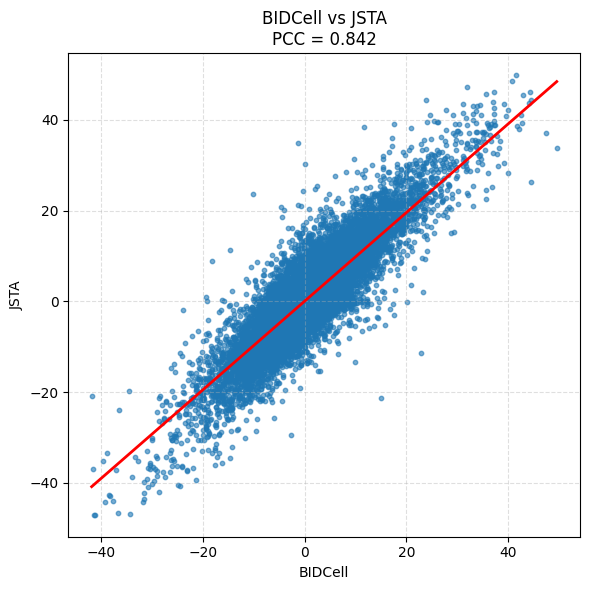

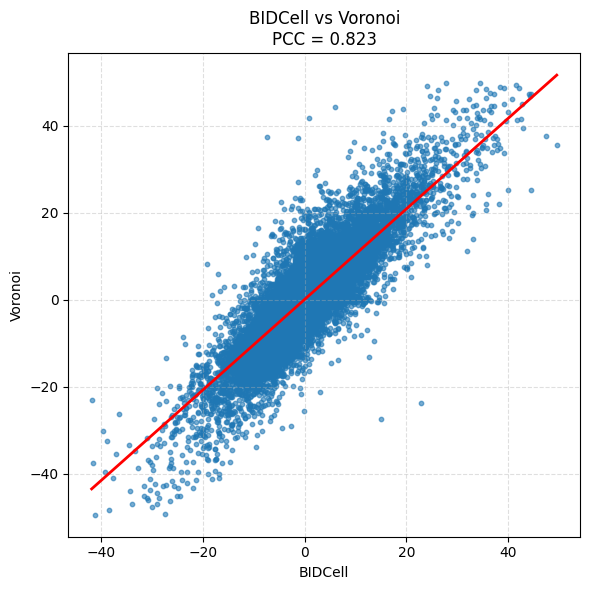

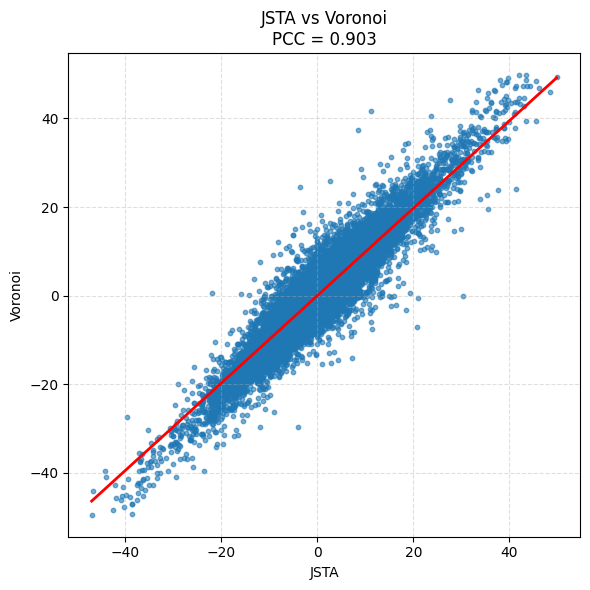

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# --------- Config ---------
paths = {
    "BIDCell": "../BIDCell/network/significant_network/sample01.csv",
    "JSTA":    "../JSTA/network/significant_network/sample01.csv",
    "Voronoi": "../v/network/significant_network/sample01.csv"
}

THRESH = 50  # Threshold for outlier filtering

# --------- Load & flatten ---------
def load_and_flatten(path: str) -> np.ndarray:
    df = pd.read_csv(path, index_col=0)
    return df.to_numpy().ravel()

data = {name: load_and_flatten(p) for name, p in paths.items()}

# --------- Pairwise plotting ---------
def plot_pair(name_x: str, name_y: str, x_raw: np.ndarray, y_raw: np.ndarray, thresh: float = 50):
    finite_mask = np.isfinite(x_raw) & np.isfinite(y_raw)
    thresh_mask = (np.abs(x_raw) <= thresh) & (np.abs(y_raw) <= thresh)
    mask = finite_mask & thresh_mask

    x = x_raw[mask]
    y = y_raw[mask]

    if x.size == 0:
        raise ValueError(f"No data left after filtering for pair {name_x} vs {name_y}.")

    # Pearson correlation
    pcc, _ = pearsonr(x, y)

    # Fit line
    X = x.reshape(-1, 1)
    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)

    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=10, alpha=0.6)
    sort_idx = np.argsort(x)
    plt.plot(x[sort_idx], y_pred[sort_idx], linewidth=2, color="red")
    plt.xlabel(name_x)
    plt.ylabel(name_y)
    plt.title(f"{name_x} vs {name_y}\nPCC = {pcc:.3f}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

# Define pairs and plot
pairs = [("BIDCell", "JSTA"), ("BIDCell", "Voronoi"), ("JSTA", "Voronoi")]
for a, b in pairs:
    plot_pair(a, b, data[a], data[b], thresh=THRESH)
